In [61]:
##Uncomment to install needed dependencies.
%pip install qiskit
%pip install pylatexenc

In [62]:
import scipy
import numpy as np
import matplotlib
from matplotlib import pyplot as plt
import pandas as pd
import random
import copy

import qiskit
from qiskit.quantum_info import SparsePauliOp
from qiskit.circuit.library import HGate, XGate, CXGate, RYGate

# Project Overview: Genetic Algorithms for the Variational Quantum Eigensolver
Goal: find the (approximate) ground state and corresponding energy for some Hamiltonian matrix $H$ using the variational approach: that is, guess-and-check quantum states, compute the expectation value of $H$ in that state, and hunt for the state that yields the minimum output. The variational principle says that this is the ground state of the system.

In our case, we will use Hamiltonians in a simple class: a transverse-field Ising model on a chain of $n$ spins (with index $i$ ranging from 0 to $n-1$), corresponding to a system of magnetic spins with nearest-neighbor interactions, immersed in an external magnetic field:
$$H = - J \sum_{i=0}^{n-1} Z_i Z_{i+1} - h \sum_{i=0}^n X_i$$
where $i$ indicates that the Pauli operator acts on the $i$th element of the chain. In practice, we will represent action on different qubits through a kronecker product.

## Where does the quantum speedup occur?
The classical work flow would involve guessing the form of the ground state as a function of some tunable parameters $\theta$, i.e. $|\psi(\theta_i)>$ where $i=0...N-1$ has as many entries as the number of qubits. Then, we need to compute the expectation value of this $N$-dimensional vector with respect to $H$, i.e. the matrix inner product $< \psi | H | \psi>$. This multiplication involves $N^2$ steps, and must be done at *each* step of the classical minimization procedure that searches for $\theta_i$.

In the quantum version, this $O(N^2)$ step process is simplified down to making a measurement on the quantum circuit that outputs $<H>_{|\psi>}$. If we get lucky (and in many physical applications in chemistry etc. there is reason to believe we will be), $H$ will be relatively sparse, and composed of a relatively small number of Pauli operators (or at least, a reasonable number of operators that commute with each other, so we can measure them simultaneously without having to re-prepare the circuit) that can be measured easily on the quantum computer. In this way, the $O(N^2)$-step process can be reduced to a series of measurements.

There are obstructions to the efficiency of this process, however- for instance, the expectation value of a matrix must be determined from the *statistics of many repeated measurements*- if an extremely high degree of accuracy is demanded, the number of repeated measurements may outweigh the efficiency gains of avoiding computing the matrix inner product.

## Genetic Algorithm
The genetic algorithm is a machine learning parameter-update algorithm one can employ for essentially any optimization task that you want to optimize performance on- for example, to find the weights of a neural network that optimize accuracy of the $in \to out$ prediction map, etc.

Each single guess/attempt at the solution is an "individual". We initialize a set of individuals with random-ish properties (i.e. guess random weights $W$ in the neural net). In practice, the population is best stored as a list of classes, with each class representing an individual. We then have the individuals "compete" in a Darwinian "tournament" step, and only keep the survivors (i.e. the ones with better performance). We can then have these survivors generate the next generation by crossing over genes (i.e. a child has genes 1-3 from parent 1, and 4-10 from parent 2), with the addition of a mutation step that can randomly change a gene with some probability. The children then become the parents in the population, and we begin again. This evolutionary process ensures only better-fitting individuals (at least in the local minimum sense) are produced in subsequent generations; the mutation step helps promote exploration beyond local minima.

In summary, the steps of a genetic algorithm are:
- First time only: initialize population of individuals with random attributes
1. Have individuals compete in tournament, discard losers
2. Have winners produce children via crossover
3. Act randomly on the children by mutation
4. Set population = children
5. Repeat

We will consider quantum circuits with genes being their gate topology. Circuit designs will be randomly initialized, "compete" in a Darwinian "tournament" from which we will keep the winners. We will then have these winners "reproduce" by splicing their genes onto one another and mutating them (in the form of random gate deletions, additions, or swaps). This will help us locate the circuit that prepares the ground state of a given Hamiltonian rather rapidly.

# Two-Dimensional Case ($i=2$)- Getting used to Qiskit.
This case will allow us to manually write the Hamiltonian, and essentially not have to worry too much about the quality of the circuit ansatze we think prepares the ground state before we have the algorithm up and running.

## Defining the Hamiltonian
Can be done using numpy arrays, or built-in Qiskit modules like SparsePauliOp.

In [63]:
##Interaction and magnetic field strengths: (POSITIVE by convention)
J = 1.0
h = 1.0

In [64]:
# ###Numpy approach: (we will not use this)
# I = np.eye(2) #2x2 Identity

# X = np.array([
#     [0,1],
#     [1,0]])

# Z = np.array([
#     [1,0],
#     [0,-1]])

# H = (
#     -J*np.kron(Z,Z)
#     -h*np.kron(X,I)
#     -h*np.kron(I,X))

# print(H)

In [65]:
###Qiskit approach (more modular)

H = SparsePauliOp.from_list([
    ("ZZ",-J),
    ("XI",-h),
    ("IX",-h)])

print(H)

SparsePauliOp(['ZZ', 'XI', 'IX'],
              coeffs=[-1.+0.j, -1.+0.j, -1.+0.j])


### Finding exact ground state and energy for 2-qubit Ising (for comparison/sanity checking)

In [66]:
eigvals, eigvecs = np.linalg.eigh(H)

ground_energy = eigvals[0]
ground_state = eigvecs[:,0]
print("Ground state:", ground_state)
print("Ground state energy =", ground_energy)

Ground state: [0.60150096+0.j 0.37174803+0.j 0.37174803+0.j 0.60150096+0.j]
Ground state energy = -2.23606797749979


## Making a quantum circuit to prepare states for testing
This circuit is a ctrl-X (CNOT) gate preceded by two rotation operators with parameter vector `theta = [theta[0],theta[1]` that controls the strength of the rotation on qubit zero and 1.

We can then extract the output statevector these gates yield by using `qiskit.quantum_into.Statevector.from_instruction`, and then extracting the `data` attribute of the produced (abstract state class) `psi`.

We can then compute the energy of this guessed state, again either using numpy operations (vector daggered, dotted into Hamiltonian, dotted into vector) or built-in Qiskit methods.

In [67]:
def make_circuit(theta):
    #Intakes two parameters corresponding to initial rotation gates.
    #Returns a circuit object

    qc = qiskit.QuantumCircuit(2) #Initializes quantum circuit with 2-qubit register
    qc.ry(theta[0],0)  #Adds a rotation gate to qubit zero, of angle theta[0]
    qc.ry(theta[1],1)
    qc.cx(0,1) #Adds a controlled x gate with control qubit 0 and target qubit 1

    return qc

test_theta = [.1,.1]

test_qc = make_circuit(test_theta)
test_psi = qiskit.quantum_info.Statevector.from_instruction(test_qc)
test_energy_value = test_psi.expectation_value(H)

print("Energy corresponding to prepared psi with theta parameter vector", test_theta, ":   ", test_energy_value)

Energy corresponding to prepared psi with theta parameter vector [0.1, 0.1] :    (-1.1048042930042332+0j)


## Define energy functional of input parameters
For resuable calculations: intakes vector of parameters, determines quantum state outputted by those parameters, and outputs the expectation value of H for that quantum state.

Thus, this is a function we can optimize with respect to the intake parameters using optimization libraries like scipy.optimize.minimize

In [68]:
from scipy.optimize import minimize
theta0 = np.random.randn(2)

def energy(theta):
    qc = make_circuit(theta) #Makes circuit with those input values
    psi = qiskit.quantum_info.Statevector.from_instruction(qc) #Computes outputted state
    # state = psi.data; H_matrix = H.to_matrix(); expval_energy = np.real(state.conj().T @ H_matrix @ state) #This is an ALTERNATE way to compute energy that converts H and psi to matrix and vector.
    expval_energy = psi.expectation_value(H)  #Built-in expectation value attribute of qiskit objects. Allows us to leave psi and H as Statevector and SparsePauliOp types rather than converting to matrices.
    return np.real(expval_energy) #Returns expval of Hamiltonian on this state (applies np.real to ensure complex number is re-formatted as a real number, otherwise optimizers crash)

test_energy = energy([.1,.1])
print("Test energy:", test_energy)

Test energy: -1.1048042930042332


## Numerically minimizing the energy/determining values of the theta parameters that yield the ground state

In [69]:
result = minimize(
    energy,
    theta0,
    method="COBYLA")

print("Result:", result)

Result:  message: Return from COBYLA because the trust region radius reaches its lower bound.
 success: True
  status: 0
     fun: -2.236067975301606
       x: [ 1.571e+00  1.107e+00]
    nfev: 52
   maxcv: 0.0


## Plotting circuit that prepares the numerically-computed ground state

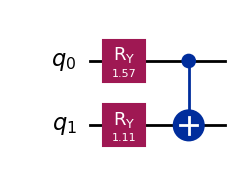

In [70]:
best_qc = make_circuit(result.x) #extracts the parameters of the optimized ground state, which is stored in result.x. This is then fed in as the theta array to create the best circuit.
best_qc.draw("mpl") #Draws circuit (requires installing matplotlib dependency and restarting Kernel)

## Conclusion for 2-qubit Ising model:
We see the numerical optimization of the Qiskit circuit yielded a ground state energy of -2.23, in agreement with the analytical result.

# $n$-qubit Transverse-Field Ising Model
With $n>2$ qubits we will take the opportunity to get used to more reproducible, loop-based methods for generating the Pauli strings (in the 2 qubit case we hard-coded them).

In practice, this is achievable by joining together letters using the `"".join(my_array)` to connect the strings into one string, packaging the result into a list of the form `[XIZZ, coefficient]`, putting each of these into an array called "terms", and then passing that entire array to `SparsePauliOp.from_list(terms)`.

## Function that generates $n$-qubit Ising Hamiltonian: ($n=10$ in examples)

In [71]:
def transverse_ising_hamiltonian(n_qubits, J, h):
    terms = []  #Will eventually be used to generate the SparsePauliOp. Each entry will be a 2-array of the form ['XIZZ', J_coefficient]

    for i in range(n_qubits-1): #Indices go from 0 to n_qubits-2, so the final pauli string has Z_{i=n-2}Z_{i=n-1}, which is good- recall that i=n-1 is the last bit's index since we started at zero.
        pauli_string_array = ["I"]*n_qubits #Initializes the Pauli string as an array which we will later join to a single word. Just ["I", "I", "I"...] to start.
        pauli_string_array[i] = "Z"
        pauli_string_array[i+1] = "Z"
        joined_string = "".join(pauli_string_array) #Creates string of the form "IIIZZIIII"
        terms.append([joined_string, -J]) #Adds this term to the list "terms"
    for i in range(n_qubits): #Handles the X terms
        pauli_string_array = ["I"]*n_qubits #Initializes the Pauli string as an array which we will later join to a single word. Just ["I", "I", "I"...] to start.
        pauli_string_array[i] = "X"
        joined_string = "".join(pauli_string_array) #Creates string of the form "IIIZZIIII"
        terms.append([joined_string, -h]) #Adds this term to the list "terms"

    return SparsePauliOp.from_list(terms) #Returns a SparsePauliOp object from qiskit, with terms like ["ZZII", -J], ["IIIX", -h] fed in as a list "terms", which is then converted to a Pauli op using the .from_list method.

my_hamiltonian = transverse_ising_hamiltonian(10,1,1)
print(my_hamiltonian.to_matrix())
###Exact ground state of system:
eigvals, eigvecs = np.linalg.eigh(my_hamiltonian)
ground_energy = eigvals[0]
ground_state = eigvecs[:,0]
print("Ground state:", ground_state)
print("Ground state energy =", ground_energy)

[[-9.+0.j -1.+0.j -1.+0.j ...  0.+0.j  0.+0.j  0.+0.j]
 [-1.+0.j -7.+0.j  0.+0.j ...  0.+0.j  0.+0.j  0.+0.j]
 [-1.+0.j  0.+0.j -5.+0.j ...  0.+0.j  0.+0.j  0.+0.j]
 ...
 [ 0.+0.j  0.+0.j  0.+0.j ... -5.+0.j  0.+0.j -1.+0.j]
 [ 0.+0.j  0.+0.j  0.+0.j ...  0.+0.j -7.+0.j -1.+0.j]
 [ 0.+0.j  0.+0.j  0.+0.j ... -1.+0.j -1.+0.j -9.+0.j]]
Ground state: [-0.29339911+0.j -0.14835658+0.j -0.09318807+0.j ... -0.09318807+0.j
 -0.14835658+0.j -0.29339911+0.j]
Ground state energy = -12.381489999654757


### Make elementary modular circuit preparer for $n$-qubit circuit
This will have a fixed list of gates for now, $R_y$ gates followed by a layer of controlled-X gates.

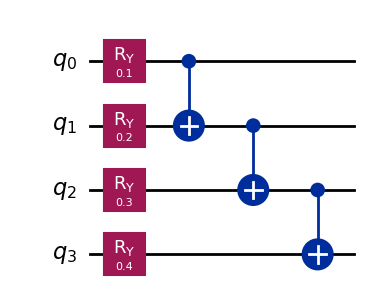

In [72]:
def prepare_circuit(n_qubits, theta):
    ###Generates a circuit with n Ry gates of rotation parameter theta[i], followed by entanglement by n-1 cnot/cx gates
    qc = qiskit.QuantumCircuit(n_qubits) #Initializes quantum circuit with 2-qubit register
    for i in range(n_qubits):
        qc.ry(theta[i],i)  #Adds a rotation gate to qubit zero, of angle theta[0]
    for i in range(n_qubits-1):
        qc.cx(i,i+1) #Adds a controlled x gate with control qubit 0 and target qubit 1
    return qc


###Test- make a 4-qubit circuit with random
test_qc = prepare_circuit(4,[.1,.2,.3,.4])
test_qc.draw("mpl")

### Use numerical/scipy methods to solve eigenvalues/eigenvectors of Hamiltonian:

In [73]:
from scipy.optimize import minimize

def energy(theta_array):  #Given a fixed circuit geometry "prepare_circuit" and an explicit value for all theta parameters in the circuit, computes energy of corresponding state w.r.t. H
    qc = prepare_circuit(n_qubits, theta_array)
    psi = qiskit.quantum_info.Statevector.from_instruction(qc) #Computes the state prepared by that circuit
    expval_energy = psi.expectation_value(H)  #Built-in expectation value attribute of qiskit objects. Allows us to leave psi and H as Statevector and SparsePauliOp types rather than converting to matrices.
    return np.real(expval_energy) #Returns expval of Hamiltonian on this state (applies np.real to ensure complex number is re-formatted as a real number, otherwise optimizers crash)

###Test calculation- find the energy of a random choice of circuit theta parameters and Hamiltonian.
n_qubits = 10
H = transverse_ising_hamiltonian(n_qubits,J=1,h=1)

test_energy = energy(theta_array = [0,.1,.2,.3, 0,.1,.2,.3, 0,.1])
print("Test energy:", test_energy)


###Test calculation- use scipy's minimize to find theta values corresponding to the minimum energy (at least, the minimum energy preparable by a circuit of this topology)
result = minimize(
    energy, #Assumes this is a function with one argument, which the optimizer will output as "x". Really, it is the theta_array of optimal energy which will be outputted.
    np.random.uniform(
        -np.pi,
        np.pi,
        size=n_qubits), #Initial guess
    method="COBYLA")

print("Resulting theta array:", result.x, "and corresponding energy:", result.fun)
print("compared to the analytical answer of ground state energy (computed a cell above via diagonalization) of", ground_energy)

qc_result = prepare_circuit(n_qubits, result.x)
print("Circuit preparing ground state:")
print(qc_result)

Test energy: -9.112741325954671
Resulting theta array: [1.57072136 1.07927153 1.05112883 1.04768911 1.04725072 1.04728684
 1.0472762  7.3308601  1.05111423 1.07933744] and corresponding energy: -12.234201155729693
compared to the analytical answer of ground state energy (computed a cell above via diagonalization) of -12.381489999654757
Circuit preparing ground state:
     ┌────────────┐                                             
q_0: ┤ Ry(1.5707) ├──■──────────────────────────────────────────
     ├────────────┤┌─┴─┐                                        
q_1: ┤ Ry(1.0793) ├┤ X ├──■─────────────────────────────────────
     ├────────────┤└───┘┌─┴─┐                                   
q_2: ┤ Ry(1.0511) ├─────┤ X ├──■────────────────────────────────
     ├────────────┤     └───┘┌─┴─┐                              
q_3: ┤ Ry(1.0477) ├──────────┤ X ├──■───────────────────────────
     ├────────────┤          └───┘┌─┴─┐                         
q_4: ┤ Ry(1.0473) ├───────────────┤ X ├──■───

## Adding multiple trials to avoid local minima


In [74]:
###Checks by iterating over a couple of trials that we have not just found a local minimum of energy
best_E = np.inf
best_result = None
num_trials = 5

for trial in range(num_trials):
    theta0 = np.random.uniform(
        -np.pi,
        np.pi,
        size=10)

    result = minimize(
        energy,
        theta0,
        method="COBYLA")

    if result.fun < best_E:
        best_E = result.fun
        best_result = result

print("Best theta array:", best_result.x, "and corresponding energy:", best_result.fun)
print("compared to the analytical answer of ground state energy (computed a cell above via diagonalization) of", ground_energy)

Best theta array: [1.57084759 1.07927927 1.05111556 1.04765899 1.04722581 1.04719575
 1.04721702 1.04768278 1.0511186  1.07927917] and corresponding energy: -12.234201162609184
compared to the analytical answer of ground state energy (computed a cell above via diagonalization) of -12.381489999654757


## Conclusion for $n$-qubit optimization:
The ground state energy computed by minimizing $<H>$ by varying $\theta$ in the quantum circuit agreed with the analytical case to within 1% (12.23 vs 12.38 ground state energies).

# PART 2- The Genetic Algorithm

In this genetic algorithm, each individual will be a quantum circuit, with the unique geometry/gate pattern of that individual comprising its "genome". We will *not* include the $\theta_i$ as part of the genome, since we will have to classically re-optimize these parameters each time we generate a new circuit anyways. In other words, the *true* search that the genetic algorithm is performing is *not for the parameters $\theta_i$, but rather the pattern/depth of gates a circuit should have* that most efficiently prepares the quantum state corresponding to the ground state of $H$.

The algorithm will pit different individuals against each other- ones with a layer of $R_y$ gates at the beginning, ones with additional layers of CNOT/CX gates, additional layers, etc. Whichever one has higher "fitness" as measured by a fitness function (relating to the resulting clasically-optimized ground state energy corresponding to that circuit geometry), will be deemed a survivor worthy of generating the next generation; from the survivors we will mix the genomes, i.e. splicing the gates of successful circuits onto one another, and then mutating circuits by adding or deleting random gates, or replacing gates with other gates randomly. This will ensure adequate exploration of the parameter search space beyond the starting population.

The below functions will fully modular-ize the above code, allowing for the random creation of gates and automatic handling of circuits with a differing number of gates/geometry. Functions are described in comments next to their definitions in the code.



In [82]:
def create_quantum_circuit(list_of_gates, list_of_theta_values):  #Creates a qiskit quantum circuit object from a list of gates, and a list of theta values for use in rotation_y gates.
    # print("Creating quantum circuit! Length of list of gates:", len(list_of_gates), "and list of theta values:", len(list_of_theta_values), ".  Number of Ry gates:", calc_number_and_location_of_Ry_gates(list_of_gates)[0])
    qc = qiskit.QuantumCircuit(n_qubits) #n_qubits is global variable
    theta_counter = 0 #Will be used to deploy the theta variables in with the y gates only. Will increment each time a y gate is filled.
    for gate, qubits in list_of_gates:
        if gate == "h":
            qc.h(qubits[0])
        elif gate == "x":
            qc.x(qubits[0])
        elif gate == "cx":
            qc.cx(qubits[0], qubits[1])
        elif gate == "ry":
            qc.ry(list_of_theta_values[theta_counter],qubits[0])
            theta_counter += 1
    return qc

def create_list_of_thetas(list_of_gates):  #Automatically detects how many rotational_y gates are in the circuit and supplies a list of random angles of that length. For use in initial guesses for optimization of those angles.
    number_of_thetas = calc_number_and_location_of_Ry_gates(list_of_gates)[0]
    list_of_thetas = np.random.uniform(-np.pi, np.pi, size=number_of_thetas)
    return list_of_thetas

def calc_number_and_location_of_Ry_gates(list_of_gates): #Calculates the number of Ry gates in the circuit (needed for knowing how many theta_i we will optimize w.r.t.)
    total_number_of_y_gates = 0
    list_of_indices_with_y_gates = []
    for i in range(len(list_of_gates)):
        if list_of_gates[i][0] == "ry":
            total_number_of_y_gates += 1
            list_of_indices_with_y_gates.append(i)
    return total_number_of_y_gates, list_of_indices_with_y_gates #For now, second argument is redundant, but may be needed for mutations and such.


def calculate_energy(list_of_theta_values, list_of_gates): #For a GIVEN value of theta, calculates <H>_\psi. This is really only used for circuits without R_y gates.
                                                            #For circuits with R_y gates, we will optimize with respect to theta and only use theta values as initial guesses for the minimizer.
    qc = create_quantum_circuit(list_of_gates, list_of_theta_values)
    psi = qiskit.quantum_info.Statevector.from_instruction(qc) #Computes the state prepared by that circuit
    expval_energy = psi.expectation_value(H)  #Built-in expectation value attribute of qiskit objects. Allows us to leave psi and H as Statevector and SparsePauliOp types rather than converting to matrices.
    return np.real(expval_energy)

def calculate_ground_state_energy_and_theta(list_of_theta_values, list_of_gates):  #Given a list of *initial* theta values, optimizes to find the theta values outputting minimal <H>_\psi(\theta).
    number_of_theta_values = len(list_of_theta_values)
    if number_of_theta_values == 0: #If there are no Ry gates, there is nothing to optimize. Just return the energy of the circuit as-is.
        # print("There are no theta values/Ry gates in this circuit. Returning immediate energy.")
        return calculate_energy(list_of_theta_values, list_of_gates), [] #The empty list matches the formatting of the other case, which must also return the theta array corresponding to the best configuration

    best_E = np.inf  #Variable where the best energy will be located
    best_result = None #and the best result output of the minimize method (also contains a redundant copy of the energy)

    for trial in range(num_trials):
        theta0 = np.random.uniform(
            -np.pi,
            np.pi,
            size=number_of_theta_values)

        result = minimize(
            calculate_energy, #Function to be minimized, viewed as having parameters theta, and fixed arguments given by the gates
            theta0, #Initial guess
            method="COBYLA",
            args=list_of_gates)

        if result.fun < best_E:
            best_E = result.fun
            best_result = result

    ground_energy = result.fun
    minimal_theta_array = result.x
    return ground_energy, minimal_theta_array



class individual:
    #Creates a class instance of a typical individual in the population. Each individual is represented by (more or less) a list of gates.
    #Some methods are available to update attributes (namely the energy/fitness scores) upon, say, mutation.
    def __init__(self, list_of_gates):
        self.list_of_gates = list_of_gates
        self.number_of_gates = len(list_of_gates)
        self.number_of_Ry_gates = calc_number_and_location_of_Ry_gates(list_of_gates)[0]
        self.ground_state_energy = None
        self.fitness = None
        self.best_theta_values = None
    def calc_fitness(self):
        list_of_gates = self.list_of_gates
        list_of_thetas = create_list_of_thetas(list_of_gates)
        ground_state_energy, best_theta_values = calculate_ground_state_energy_and_theta(list_of_thetas, list_of_gates)
        self.ground_state_energy = ground_state_energy
        self.best_theta_values = best_theta_values
        self.fitness = fitness_score(list_of_gates, ground_state_energy)
    def display(self):#NOTE- this will error if you have not yet computed a list_of_theta_values for the circuit (unless the circuit does not have any Ry values).
        #To remedy this, you must first use calc_fitness on the individual to fill in its best_theta_values attribute, and can then run this.
        print(create_quantum_circuit(self.list_of_gates, self.best_theta_values))

def fitness_score(list_of_gates, ground_state_energy):   #User-defined fitness function. Generally, it is fitness = - E - (penalty for increasing number of gates)
    number_of_gates = len(list_of_gates)
    number_of_Ry_gates = calc_number_and_location_of_Ry_gates(list_of_gates)[0]
    fitness = - ground_state_energy - depth_penalty * number_of_gates - Ry_penalty * number_of_Ry_gates  #F = - E - lambda N - lambda_y N_y.  Penalizes more gates, especially Ry gates.
    return fitness


########################Genetic algorithm related function definitions
def tournament(individual_1, individual_2):  #Compares two individuals, selects one with higher fitness level
    fitness_1 = individual_1.fitness; fitness_2 = individual_2.fitness
    if fitness_1 == None: #Calculates fitness if not done already
        individual_1.calc_fitness()
        fitness_1 = individual_1.fitness
    if fitness_2 == None:
        individual_2.calc_fitness()
        fitness_2 = individual_2.fitness

    if fitness_1 >= fitness_2:
        # print("Individual 1 survives")
        return individual_1
    else:
        # print("Individual 2 survives")
        return individual_2

# survivor = tournament(my_individual, my_individual_2)
# print("Survivor:", survivor)
# survivor.display()


def mutate(individual): #Mutates a circuit by messing with its gates
    #This will act via shallow copy, i.e. it will modify the genome in place!
    genome = individual.list_of_gates
    length_of_genome = len(genome)
    if random.random() <= mutation_rate:
        # print("Mutation occurring!")

        ###1/3 probability for each mutation. Roll a dice and see what happens
        which_mutation_random_number = random.random()
        if which_mutation_random_number <= 0.3333: #Change gate
            if length_of_genome == 0:
                    # print("WHOA NELLY!!!!\n\nMutation aborted- can't modify gate from a circuit with 0 gates")
                    pass
            else:
                gate_index_to_be_mutated = random.randint(0,length_of_genome-1)
                # print("Gate change occuring at index", gate_index_to_be_mutated)
                genome[gate_index_to_be_mutated] = random_gate_and_qubit()  #Swaps current gate to be equal to the new random gate
        elif which_mutation_random_number <= 0.6666: #Add gate
            gate_index_to_add_at = random.randint(0,length_of_genome)
            # print("Gate addition occuring at index", gate_index_to_add_at)
            genome.insert(gate_index_to_add_at, random_gate_and_qubit()) #Adds random gate at this index
        else: #Delete gate
            if length_of_genome == 0:
                # print("WHOA NELLY!!!!\n\nMutation aborted- can't delete gate from a circuit with 0 gates")
                pass
            else: #Proceed
                gate_index_to_delete_at = random.randint(0,length_of_genome-1)
                # print("Gate deletion occuring at index", gate_index_to_delete_at)
                genome.pop(gate_index_to_delete_at)  #Deletes this gate
                # print("If I made it here, the pop function is working properly.")
        # print("Mutation complete. New genome:", genome)
    else:
        # print("No mutation occurring.")
        pass


def random_gate_and_qubit():  #Helper function that creates a random gate somewhere in a circuit. Also used during population initialization
    random_gate_type = random.choice(["x", "h", "cx", "ry"])
    if random_gate_type == "cx":
        random_qubit = random.sample(range(0, n_qubits), 2) #Gets two different qubits for a cx gate
    else:
        random_qubit = [random.randint(0,n_qubits-1)]
    # print("Random gate has been created for some purpose! Gate type and qubit:", (random_gate_type, random_qubit))
    return (random_gate_type, random_qubit)


# mutate(my_individual)
# my_list_of_gates = my_individual.list_of_gates
# my_best_theta = my_individual.best_theta_values
# print("List of gates:", my_list_of_gates)
# print("Best theta values:", my_best_theta)

# qc = create_quantum_circuit(my_list_of_gates, my_best_theta)
# print(qc)

# my_individual.display()

def crossover(individual_1, individual_2):  #Splices genes from two individuals to create a new individual (presumably two tournament winners)
    genome_1 = individual_1.list_of_gates; genome_2 = individual_2.list_of_gates
    length_of_genome_1 = len(genome_1); length_of_genome_2 = len(genome_2)

    limit_of_genome_1 = random.randint(0, length_of_genome_1)
    limit_of_genome_2 = random.randint(0, length_of_genome_2)

    new_genome = genome_1[:limit_of_genome_1] + genome_2[limit_of_genome_2:]

    new_individual = individual(new_genome)
    return new_individual

# new_individual = crossover(my_individual, my_individual_2)
# new_individual.calc_fitness()
# print("Genome:", new_individual.list_of_gates)

############################################Functions relating to population generation/initialization##############

def create_random_list_of_gates(limit_on_number_of_gates):
    list_of_gates = []
    number_of_gates_to_use_for_this_individual = random.randint(0,limit_on_number_of_gates)
    for i in range(0,number_of_gates_to_use_for_this_individual):
        list_of_gates.append(random_gate_and_qubit())
    return list_of_gates

# create_random_list_of_gates(5)

def create_population(population_size):
    population = []
    for i in range(population_size):
        list_of_gates_to_add = create_random_list_of_gates(limit_on_number_of_gates)
        # print("List of gates this indiviudal will be initialized with:", list_of_gates_to_add)
        an_individual = individual(list_of_gates_to_add)
        population.append(an_individual)
    return population

# population = create_population(initial_population_size)
###################################################################################################

########################################Population statistics##############################################

def find_best_individual(population):
    best_fitness = -np.inf
    best_individual = None
    # print("Starting going through members!")
    for member in population:
        # print("Current best fitness I've seen so far:", best_fitness)
        # print("Considering an individual")
        # print("Looking at a member with fitness", member.fitness)
        if member.fitness == None: #Calculates fitness if not already computed
            # print("Individual had blank fitness. Recalculating.")
            member.calc_fitness()

        if member.fitness > best_fitness:
            # print("This member's fitness of", member.fitness, "was better than the best fitness of", best_fitness,"!  They are now the best member.")
            best_individual = member
            best_fitness = member.fitness
        else:
            # print("This member's fitness of", member.fitness, "was worse than the best fitness of", best_fitness)
            pass

    return best_individual

# debug_individual = population[0]
# print("List of gates:", debug_individual.list_of_gates)
# best_individual = find_best_individual(population)

# print("Best individual found among initial population!")
# best_individual.display()
# print("Stats: Energy:", best_individual.ground_state_energy, "and fitness", best_individual.fitness)

def find_average_fitness(population):
    fitness_scores = []
    for individual in population:
        # print("Considering an individual")
        if individual.fitness == None: #Calculates fitness if not already computed
            # print("Individual had blank fitness. Recalculating.")
            individual.calc_fitness()
        fitness_scores.append(individual.fitness)
    average_fitness = np.mean(fitness_scores)

    return average_fitness

#################################################################################################################################

#######################################Global Variables############################################
n_qubits = 10
H = transverse_ising_hamiltonian(n_qubits, J=1,h=1) #Hamiltonian to be minimized
depth_penalty = .01  #Penalty in fitness score for circuits with many gates
Ry_penalty = .01   #Penalty in fitness score specifically for Ry gates, which are discouraged.
num_trials = 5   ##Number of trials to perform during the classical minimzation over theta values. Helps avoid local minima.

mutation_rate = .4   #Fraction of the time to mutate a child circuit (among these, evenly split addition, deletion, and gate swap mutations)

initial_population_size = 30  #Initial population of circuits
limit_on_number_of_gates = 10  #When we initialize the population, at most how many gates we allow in the circuit. We randomly select an integer up to this number and then add that many gates.

number_of_generations_to_run = 10  #Number of iterations of the entire algorithm to run
number_tournaments_each_generation = 30 #Number of pairwise tournaments to perform. Also equals number of survivors of the tournaments
num_children_each_generation = initial_population_size #Equals the population of the next generation. Here it is set to keep it equal to the initial population size.
###################################################################################################

# #######################Example usage: finding the fitness score of an individual  (note: n_qubits must be >=4 for the example list of gates to make sense.)
# example_list_of_gates = [
#     ("h", [0]),       # Hadamard on qubit 0
#     ("x", [1]),       # X gate on qubit 1
#     ("cx", [0, 1])]    # CNOT with control 0 and target 1
#     # ("ry", [1]),
#     # ("ry", [3])]


# example_list_of_gates_2 = [
#     ("h", [0]),       # Hadamard on qubit 0
#     ("x", [1]),       # X gate on qubit 1
#     ("cx", [0, 1]),    # CNOT with control 0 and target 1
#     ("ry", [1]),
#     ("ry", [2])]

# print("Creating individual")
# my_individual = individual(example_list_of_gates)
# print("Applying calc_fitness method...")
# my_individual.calc_fitness()
# print("Application of method complete.\n")

# my_individual_2 = individual(example_list_of_gates_2)
# print("Applying calc_fitness method...")
# my_individual_2.calc_fitness()

# print("Ground state energy of my circuit topology:", my_individual.ground_state_energy)
# print("and best theta values for this circuit toplogy:", my_individual.best_theta_values)
# print("Fitness of this circuit topology:", my_individual.fitness)
# print("with circuit diagram"); print(create_quantum_circuit(my_individual.list_of_gates, my_individual.best_theta_values))

# print("Ground state energy of my circuit topology:", my_individual_2.ground_state_energy)
# print("and best theta values for this circuit toplogy:", my_individual_2.best_theta_values)
# print("Fitness of this circuit topology:", my_individual_2.fitness)
# print("with circuit diagram"); print(create_quantum_circuit(my_individual_2.list_of_gates, my_individual_2.best_theta_values))

In [83]:
#####################################################MAIN SIMULATION##################################################
###List and counter initializations
initial_population = create_population(initial_population_size)
print("Initial population initialized. Number of individuals:", len(initial_population))
current_population = copy.deepcopy(initial_population) #For the first iteration only, set the working population equal to the current population

current_tournament_winners = [] #Tournament winners and children will be stored here
future_children = []

generation_number = 1 #Counter for which generation we're on in the simulation
list_of_average_fitnesses = []
list_of_fitness_stddevs = []
list_of_best_individual_fitness = []

###Main loop
for current_generation_number in range(number_of_generations_to_run): #Each run of this loop corresponds to one update of a generation.
    print("###Generation", generation_number, "simulation starting now!")
    current_population_size = len(current_population)

    print("Extracting fitness scores of current population:")
    list_of_current_fitness_scores = []
    for member in current_population:
        if member.fitness == None: #Calculates fitness if not already computed
            # print("Individual had blank fitness. Recalculating.")
            member.calc_fitness()
        list_of_current_fitness_scores.append(member.fitness)
    print("List of current fitness scores:", list_of_current_fitness_scores)
    print("Standard deviation of current fitness scores:", np.std(list_of_current_fitness_scores))

    ###Putting these statistics into a list
    best_individual_of_current_gen = find_best_individual(current_population) #Will have a "free ticket" to the next generation.
    best_fitness_of_current_gen = best_individual_of_current_gen.fitness
    print("Best fitness of the current generation:", best_fitness_of_current_gen)
    list_of_best_individual_fitness.append(best_fitness_of_current_gen)
    list_of_average_fitnesses.append(find_average_fitness(current_population))
    list_of_fitness_stddevs.append(np.std(list_of_current_fitness_scores))

    print("Tournament stage:")
    for i in range(number_tournaments_each_generation): #each i represents a single tournament
        random_individual_1, random_individual_2 = random.choice(current_population), random.choice(current_population) #Choose two random individuals
        survivor = tournament(random_individual_1, random_individual_2)
        current_tournament_winners.append(survivor) #Add winner of tournament to intermediary list of tournament winners that will produce children
    print("Tournament complete. Number of tournament winners:", len(current_tournament_winners))

    print("Beginning crossovers:")
    for i in range(num_children_each_generation):
        i, j = random.randint(0,len(current_tournament_winners)-1), random.randint(0,len(current_tournament_winners)-1) #Choose two random tournament winners
        new_child = crossover(current_tournament_winners[i], current_tournament_winners[j])
        future_children.append(new_child) #Append this child to the list of children
    print("Crossovers completed! Number of children:", len(future_children))

    print("Beginning mutations:")
    mutation_counter = 0
    for i in range(len(future_children)):
        if random.random()<= mutation_rate: #If we get "lucky" enough to have a mutation:
            mutate(future_children[i])
            mutation_counter += 1
        else:
            pass
    print("Mutations finished. Number of mutations conducted:", mutation_counter)

    print("Almost done generating children- adding elite individual from current generation.")
    future_children.pop(0); future_children.append(best_individual_of_current_gen) #Removes one child and replaces with the elite individual from last generation. This ensures the best candidate is always retained.
    print("Generation of children complete!")


    print("Setting parents of next generation equal to children of this generation, and clearing tournament and children variables...")
    current_population = copy.deepcopy(future_children)


    current_tournament_winners = []
    future_children = []
    print("Complete.")

    print("###Generation", generation_number, "complete.")
    generation_number += 1 #Increment counter variable

print("###Main loop complete after", generation_number-1, "generations!")

print("Calculating fitness of final population:")
final_population = current_population
for member in final_population: #Since this generation is created outside of the loop, we must evaluate the fitnesses.
    member.calc_fitness()
fitness_scores_of_final_population = [member.fitness for member in final_population]
print("Fitness scores of final population:", fitness_scores_of_final_population)

list_of_best_individual_fitness.append(find_best_individual(final_population).fitness)
list_of_average_fitnesses.append(np.mean(fitness_scores_of_final_population))
list_of_fitness_stddevs.append(np.std(fitness_scores_of_final_population))

print("DONE--- SIMULATION COMPLETE")

Initial population initialized. Number of individuals: 30
###Generation 1 simulation starting now!
Extracting fitness scores of current population:
List of current fitness scores: [np.float64(8.36213595104714), np.float64(7.963525910116931), np.float64(6.9199999999933475), np.float64(8.126067977457184), np.float64(3.9699999999999984), np.float64(1.9599999999999993), np.float64(6.176067977486155), np.float64(4.314213562237218), np.float64(9.0), np.float64(4.540281538388115), np.float64(2.929999999696212), np.float64(5.5402815364100775), np.float64(9.394435328611369), np.float64(8.196067976134184), np.float64(9.0), np.float64(2.8999999992883065), np.float64(4.5402815398196665), np.float64(3.9299999999470363), np.float64(8.989999999999998), np.float64(5.2060679749188035), np.float64(6.99), np.float64(7.728427121910151), np.float64(2.3642135620409492), np.float64(5.352135934654041), np.float64(9.0), np.float64(3.1460679753058214), np.float64(2.9099999999999984), np.float64(7.35213595314005

In [77]:
print("Fitness scores of final population:", fitness_scores_of_final_population)

Fitness scores of final population: [np.float64(9.610281539787161), np.float64(7.35213595411452), np.float64(9.156067976158193), np.float64(8.884495086684177), np.float64(7.176067976150382), np.float64(7.412135952246505), np.float64(10.043525908396475), np.float64(9.60028153825107), np.float64(9.816349515157897), np.float64(9.60028153981007), np.float64(10.453098237645246), np.float64(8.974495101046568), np.float64(9.0), np.float64(10.699166212415726), np.float64(10.643554204913972), np.float64(9.212862454121233), np.float64(10.120563075648505), np.float64(9.798648893680205), np.float64(10.597297785544253), np.float64(10.160563069437618), np.float64(8.540281530037971), np.float64(8.630503308022533), np.float64(8.98), np.float64(9.33893042924552), np.float64(8.806349505162276), np.float64(8.994495097778573), np.float64(7.156067975904094), np.float64(10.422657970689226), np.float64(9.766349514058984), np.float64(10.473098233820838)]


## Visualization of Results: Best individual produced after simulation, and progression of average fitness as generations progressed.

In [78]:
best_individual = find_best_individual(current_population)
print("Best individual found among initial population!")
best_individual.display()

print(create_quantum_circuit(best_individual.list_of_gates, best_individual.best_theta_values))

print("Stats: Energy:", best_individual.ground_state_energy, "and fitness", best_individual.fitness)

Best individual found among initial population!
      ┌────────────┐     
q_0: ─┤ Ry(0.7854) ├─────
      └────────────┘     
q_1: ─────────────────■──
      ┌────────────┐┌─┴─┐
q_2: ─┤ Ry(0.4636) ├┤ X ├
      └────────────┘└───┘
q_3: ────────────────────
     ┌─────────────┐     
q_4: ┤ Ry(0.46366) ├─────
     └─────────────┘     
q_5: ────────────────────
                         
q_6: ────────────────────
     ┌─────────────┐     
q_7: ┤ Ry(0.49892) ├─────
     ├─────────────┤     
q_8: ┤ Ry(0.58214) ├─────
     ├─────────────┤     
q_9: ┤ Ry(0.87491) ├─────
     └─────────────┘     
      ┌────────────┐     
q_0: ─┤ Ry(0.7854) ├─────
      └────────────┘     
q_1: ─────────────────■──
      ┌────────────┐┌─┴─┐
q_2: ─┤ Ry(0.4636) ├┤ X ├
      └────────────┘└───┘
q_3: ────────────────────
     ┌─────────────┐     
q_4: ┤ Ry(0.46366) ├─────
     └─────────────┘     
q_5: ────────────────────
                         
q_6: ────────────────────
     ┌─────────────┐     
q_7: ┤ Ry(0.4989

## Metrics of Circuit Energy/Fitness Over Time

<>:6: SyntaxWarning: invalid escape sequence '\s'
<>:6: SyntaxWarning: invalid escape sequence '\s'
/tmp/ipykernel_76779/946464941.py:6: SyntaxWarning: invalid escape sequence '\s'
  plt.title("Average and Elite Fitness vs. Generation\nfor Genetically-Produced Quantum Circuits Preparing Ground State\n of the $n=10$ Ising Model (with 1 $\sigma$ error bars)")
/tmp/ipykernel_76779/946464941.py:7: UserWarning: color is redundantly defined by the 'color' keyword argument and the fmt string "k-" (-> color='k'). The keyword argument will take precedence.
  plt.plot(x, list_of_average_fitnesses, 'k-', label = "Average Individual", color = "green")


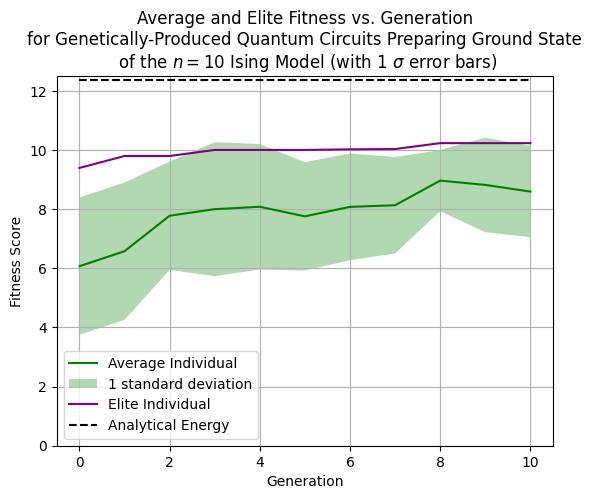

In [92]:
###Plot average fitness (and stddev of fitnesses) over time
x = np.array(range(0,number_of_generations_to_run+1))
true_energy = [12.381489999654757]*(number_of_generations_to_run+1)

plt.figure()
plt.title("Average and Elite Fitness vs. Generation\nfor Genetically-Produced Quantum Circuits Preparing Ground State\n of the $n=10$ Ising Model (with 1 $\sigma$ error bars)")
plt.plot(x, list_of_average_fitnesses, 'k-', label = "Average Individual", color = "green")
plt.fill_between(x, np.array(list_of_average_fitnesses)-np.array(list_of_fitness_stddevs), np.array(list_of_average_fitnesses)+np.array(list_of_fitness_stddevs),
                  alpha=0.3, facecolor='green', label = "1 standard deviation")
plt.plot(list_of_best_individual_fitness, label = "Elite Individual", color="purple")
plt.plot(true_energy, label = "Analytical Energy", linestyle='dashed', color="black")
plt.grid()
plt.xlabel("Generation")
plt.ylabel("Fitness Score")
plt.legend()
plt.ylim(0,12.5)
plt.show()

# Brief Conclusions
The algorithm generated a circuit capable of identifying the minimum eigenvalue to within 20% of the true eigenvalue (~10.8 depending on random seeding, vs ~12.5 exact result) for a 10-qubit system. (Already for 20 qubits the Hamiltonian cannot be stored in a performance laptop's RAM, so an analytical answer via exact diagonalization is not available.) Moreover, it did so in a gradient-free way, meaning that we were able to optimize in a way that did not rely on any notion of continuously-variable parameters, instead with us being able to delete or modify discrete quantum gates.

The VQE is a promising approach for diagonalizing extremely large matrices, especially those appearing in chemistry/physical systems which have sparse representations in terms of Pauli strings, meaning that few physical qubit measurements will be required and allowing for meaningful quantum speedup.

This work is an introductory survey into the topic, but is in line with current research such as https://arxiv.org/abs/2110.07441 and https://link.springer.com/chapter/10.1007/978-981-96-4596-1_22 in terms of its scope.

Natural next steps would be to vary which gate families are allowed (e.g. upgrade to a universal set of gates or restrict to gates most likely to generate an approximate solution, based off of the real-ity properties of a given Hamiltonian), or to integrate high-performance computing into the classical optimization steps, which still occupy a bulk of the computational time.

This investigation represents a domain of very meaningful interplay and co-integration of classical computing, quantum computing, and machine learning into one physically-meaningful application.

In [80]:
###Nicholas Pittman 6-24-2026